<a href="https://colab.research.google.com/github/phaniraghava1234/physics_informed_neural_networks/blob/main/2D_Heat_Equation_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
project_path = "/content/drive/MyDrive/ColabProjects/physics_informed_neural_networks"

os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/ColabProjects/physics_informed_neural_networks


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

# ==========================================
# 0. Device Configuration
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")


Training on device: cuda


In [4]:
# ==========================================
# 1. Exact Analytical Solution
# ==========================================
def exact_heat_solution(x, y, t, alpha):
    """
    Exact solution for 2D heat equation with:
    IC: u(x,y,0) = sin(pi*x) * sin(pi*y)
    BC: u=0 on all boundaries.
    """
    # Mathematical exact diffusion decay
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.exp(-2 * alpha * (np.pi**2) * t)

# ==========================================
# 2. Draw Geometry & System Schematic
# ==========================================
def draw_geometry():
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw 2D Plate
    rect = patches.Rectangle((0, 0), 1.0, 1.0, linewidth=3, edgecolor='black', facecolor='mistyrose')
    ax.add_patch(rect)

    # Boundary Conditions (Edges)
    ax.text(0.5, 1.05, 'Top BC: $u(x, 1, t) = 0$', ha='center', fontsize=12, color='blue', fontweight='bold')
    ax.text(0.5, -0.08, 'Bottom BC: $u(x, 0, t) = 0$', ha='center', fontsize=12, color='blue', fontweight='bold')
    ax.text(-0.05, 0.5, 'Left BC: $u(0, y, t) = 0$', va='center', ha='right', fontsize=12, color='blue', fontweight='bold', rotation=90)
    ax.text(1.05, 0.5, 'Right BC: $u(1, y, t) = 0$', va='center', ha='left', fontsize=12, color='blue', fontweight='bold', rotation=270)

    # Initial Condition (Center)
    circle = patches.Circle((0.5, 0.5), 0.3, color='red', alpha=0.4)
    ax.add_patch(circle)
    ax.text(0.5, 0.5, 'Initial Heat Spike at $t=0$\n$u(x,y,0) = \sin(\pi x)\sin(\pi y)$',
            ha='center', va='center', fontsize=12, fontweight='bold', color='darkred')

    # 3D Note
    ax.text(0.5, 0.2, 'PINN Input: $(x, y, t)$', ha='center', fontsize=14, bbox=dict(facecolor='white', alpha=0.8))

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_aspect('equal')
    ax.set_title('Problem 5: 2D Transient Heat Equation (Thermodynamics)', fontsize=15, fontweight='bold', y=1.08)
    ax.axis('off')

    plt.savefig('heat_geometry.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Geometry diagram saved as 'heat_geometry.png'")

draw_geometry()

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1425/513993216.py:32: SyntaxWarning: invalid escape sequence '\s'
  ax.text(0.5, 0.5, 'Initial Heat Spike at $t=0$\n$u(x,y,0) = \sin(\pi x)\sin(\pi y)$',


Geometry diagram saved as 'heat_geometry.png'


In [5]:
# ==========================================
# 3. Neural Network Architecture
# ==========================================
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.activation = nn.Tanh()
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])

        for i in range(len(layers)-1):
            nn.init.xavier_normal_(self.linears[i].weight)
            nn.init.zeros_(self.linears[i].bias)

    def forward(self, x, y, t):
        # The network now takes 3 inputs simultaneously
        a = torch.cat([x, y, t], dim=1)
        for i in range(len(self.linears) - 1):
            a = self.activation(self.linears[i](a))
        return self.linears[-1](a)

# ==========================================
# 4. Physics-Informed Loss Components
# ==========================================
def compute_physics_loss(model, x_f, y_f, t_f, alpha):
    x_f.requires_grad_(True)
    y_f.requires_grad_(True)
    t_f.requires_grad_(True)

    u = model(x_f, y_f, t_f)

    # Time derivative
    u_t = torch.autograd.grad(u, t_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    # Spatial derivatives
    u_x = torch.autograd.grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y_f, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    # 2D Heat Equation: du/dt = alpha * (d2u/dx2 + d2u/dy2)
    f_heat = u_t - alpha * (u_xx + u_yy)

    return torch.mean(f_heat**2)

# ==========================================
# 5. Training Data & Setup
# ==========================================
alpha = 1.0 / (2 * np.pi**2) # Diffusivity constant
N_bc = 800    # Boundary condition points
N_ic = 800    # Initial condition points
N_f = 15000   # Collocation points inside the 3D volume (x,y,t)

# 1. Collocation Points (Inside the 3D block: x, y, t)
x_f = np.random.uniform(0, 1, (N_f, 1))
y_f = np.random.uniform(0, 1, (N_f, 1))
t_f = np.random.uniform(0, 1, (N_f, 1))

x_f_pt = torch.tensor(x_f, dtype=torch.float32, device=device)
y_f_pt = torch.tensor(y_f, dtype=torch.float32, device=device)
t_f_pt = torch.tensor(t_f, dtype=torch.float32, device=device)

# 2. Initial Condition Points (t=0)
x_ic = np.random.uniform(0, 1, (N_ic, 1))
y_ic = np.random.uniform(0, 1, (N_ic, 1))
t_ic = np.zeros((N_ic, 1))
u_ic = np.sin(np.pi * x_ic) * np.sin(np.pi * y_ic)

x_ic_pt = torch.tensor(x_ic, dtype=torch.float32, device=device)
y_ic_pt = torch.tensor(y_ic, dtype=torch.float32, device=device)
t_ic_pt = torch.tensor(t_ic, dtype=torch.float32, device=device)
u_ic_pt = torch.tensor(u_ic, dtype=torch.float32, device=device)

# 3. Boundary Condition Points (x=0, x=1, y=0, y=1 for random t)
# Left/Right edges
x_bc_x = np.vstack([np.zeros((N_bc//2, 1)), np.ones((N_bc//2, 1))])
y_bc_x = np.random.uniform(0, 1, (N_bc, 1))
t_bc_x = np.random.uniform(0, 1, (N_bc, 1))

# Bottom/Top edges
x_bc_y = np.random.uniform(0, 1, (N_bc, 1))
y_bc_y = np.vstack([np.zeros((N_bc//2, 1)), np.ones((N_bc//2, 1))])
t_bc_y = np.random.uniform(0, 1, (N_bc, 1))

x_bc = np.vstack([x_bc_x, x_bc_y])
y_bc = np.vstack([y_bc_x, y_bc_y])
t_bc = np.vstack([t_bc_x, t_bc_y])
u_bc = np.zeros((2 * N_bc, 1)) # Temperature is 0 at boundaries

x_bc_pt = torch.tensor(x_bc, dtype=torch.float32, device=device)
y_bc_pt = torch.tensor(y_bc, dtype=torch.float32, device=device)
t_bc_pt = torch.tensor(t_bc, dtype=torch.float32, device=device)
u_bc_pt = torch.tensor(u_bc, dtype=torch.float32, device=device)

In [6]:
# ==========================================
# 6. Training Loop
# ==========================================
# 3 inputs (x, y, t) -> 6 layers of 64 neurons -> 1 output (u)
layers = [3, 64, 64, 64, 64, 64, 64, 1]
model = PINN(layers).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 10000

print("Starting 3D Space-Time PINN Training...")
start_time = time.time()
for epoch in range(epochs):
    optimizer.zero_grad()

    # Initial Condition Loss
    u_ic_pred = model(x_ic_pt, y_ic_pt, t_ic_pt)
    loss_ic = torch.mean((u_ic_pred - u_ic_pt)**2)

    # Boundary Condition Loss
    u_bc_pred = model(x_bc_pt, y_bc_pt, t_bc_pt)
    loss_bc = torch.mean((u_bc_pred - u_bc_pt)**2)

    # Physics Loss (inside volume)
    loss_physics = compute_physics_loss(model, x_f_pt, y_f_pt, t_f_pt, alpha)

    # Total Loss
    loss = loss_ic + loss_bc + loss_physics
    loss.backward()
    optimizer.step()

    if epoch == 6000:
        for g in optimizer.param_groups:
            g['lr'] = 1e-4

    if epoch % 1000 == 0:
        print(f'Epoch: {epoch:05d}, Total Loss: {loss.item():.6f}, Physics: {loss_physics.item():.6f}')

print(f"Training Complete in {(time.time() - start_time):.2f} seconds!")

Starting 3D Space-Time PINN Training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch: 00000, Total Loss: 0.246340, Physics: 0.005505
Epoch: 01000, Total Loss: 0.000739, Physics: 0.000283
Epoch: 02000, Total Loss: 0.000155, Physics: 0.000105
Epoch: 03000, Total Loss: 0.000054, Physics: 0.000040
Epoch: 04000, Total Loss: 0.000037, Physics: 0.000027
Epoch: 05000, Total Loss: 0.000052, Physics: 0.000022
Epoch: 06000, Total Loss: 0.000018, Physics: 0.000013
Epoch: 07000, Total Loss: 0.000016, Physics: 0.000011
Epoch: 08000, Total Loss: 0.000013, Physics: 0.000009
Epoch: 09000, Total Loss: 0.000011, Physics: 0.000008
Training Complete in 263.18 seconds!


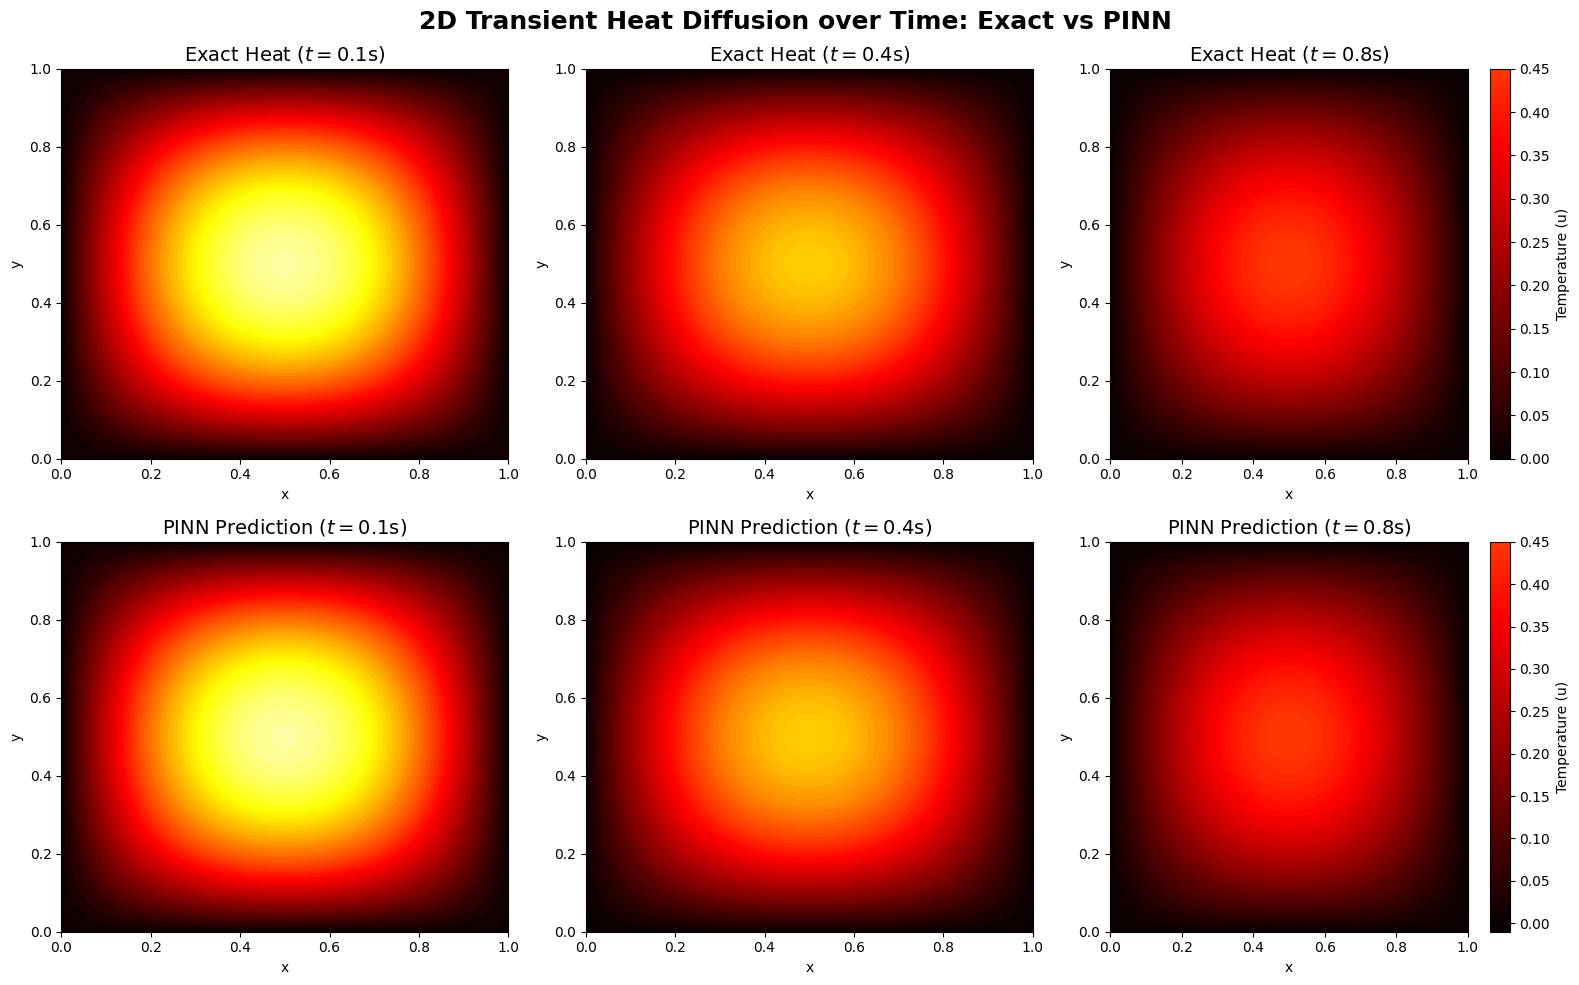

In [7]:
# ==========================================
# 7. Evaluation & Heat Map Plotting
# ==========================================
# Evaluate at three different time steps to watch the heat diffuse!
time_steps = [0.1, 0.4, 0.8]
x_grid = np.linspace(0, 1, 100)
y_grid = np.linspace(0, 1, 100)
X, Y = np.meshgrid(x_grid, y_grid)

X_flat = torch.tensor(X.flatten()[:, None], dtype=torch.float32, device=device)
Y_flat = torch.tensor(Y.flatten()[:, None], dtype=torch.float32, device=device)

fig, axs = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('2D Transient Heat Diffusion over Time: Exact vs PINN', fontsize=18, fontweight='bold')

for i, t_val in enumerate(time_steps):
    T_flat = torch.full_like(X_flat, t_val)

    # PINN Prediction
    with torch.no_grad():
        u_pred = model(X_flat, Y_flat, T_flat).cpu().numpy().reshape(100, 100)

    # Exact Mathematical Solution
    u_exact = exact_heat_solution(X, Y, t_val, alpha)

    # Plot Exact
    c1 = axs[0, i].contourf(X, Y, u_exact, 50, cmap='hot', vmin=0, vmax=1.0)
    axs[0, i].set_title(f'Exact Heat ($t={t_val}$s)', fontsize=14)
    axs[0, i].set_xlabel('x'); axs[0, i].set_ylabel('y')
    if i == 2: fig.colorbar(c1, ax=axs[0, i], label='Temperature (u)')

    # Plot PINN
    c2 = axs[1, i].contourf(X, Y, u_pred, 50, cmap='hot', vmin=0, vmax=1.0)
    axs[1, i].set_title(f'PINN Prediction ($t={t_val}$s)', fontsize=14)
    axs[1, i].set_xlabel('x'); axs[1, i].set_ylabel('y')
    if i == 2: fig.colorbar(c2, ax=axs[1, i], label='Temperature (u)')

plt.tight_layout()
plt.savefig('heat_results.png', dpi=300, bbox_inches='tight')
plt.show()